## Sign Language MNIST

Import libraries

In [26]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [27]:
print(os.listdir('../input'))

['datasets']


The next hidden code cells define functions for plotting data. Click on the "Code" button in the published kernel to reveal the hidden code.

In [28]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) / nGraphPerRow
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()


In [29]:
# Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    filename = df.dataframeName
    df = df.dropna('columns') # drop columns with NaN
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()


In [30]:
# Scatter and density plots
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]) # keep only numerical columns
    # Remove rows and columns that would lead to df being singular
    df = df.dropna('columns')
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()


Prepare data:
- Reshape "reshape(A, M, N, D)" A rows data into array of A x M x N x D
- Normalize it so values are in [0, 1]

In [31]:
train = pd.read_csv('/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv')
test  = pd.read_csv('/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv')
training_images = train.loc[:, "pixel1":"pixel784"].values.reshape(27455, 28, 28, 1) / 255.0
training_labels = train.loc[:, "label"].values
test_images = test.loc[:, "pixel1":"pixel784"].values.reshape(7172, 28, 28, 1) / 255.0
test_labels = test.loc[:, "label"].values

Train and evaluate data

In [32]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28, 28, 1)),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(25, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()
history = model.fit(training_images, training_labels, validation_data = (test_images, test_labels), epochs= 50, batch_size= 128)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780037226.231253      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780037226.237198      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,041 (336.10 KB)

 Trainable params: 86,041 (336.10 KB)

...

Epoch 1/50


I0000 00:00:1780037229.400958     131 service.cc:152] XLA service 0x7d0c08007b10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780037229.401008     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780037229.401014     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780037229.783569     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


 30/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0473 - loss: 3.2097

I0000 00:00:1780037233.044977     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


215/215 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.2487 - loss: 2.4192 - val_accuracy: 0.4891 - val_loss: 1.6144
Epoch 2/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6492 - loss: 1.0378 - val_accuracy: 0.6949 - val_loss: 0.8851
Epoch 3/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8059 - loss: 0.5632 - val_accuracy: 0.7775 - val_loss: 0.6576
Epoch 4/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8863 - loss: 0.3313 - val_accuracy: 0.8226 - val_loss: 0.5643
Epoch 5/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9290 - loss: 0.2133 - val_accuracy: 0.8526 - val_loss: 0.5041
Epoch 6/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9583 - loss: 0.1339 - val_accuracy: 0.8503 - val_loss: 0.4866
Epoch 7/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9740 - loss: 0.0876 - val_accuracy: 0.8482 - val_loss: 0.5173
Epoch 8/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9814 - loss: 0.0658 - val_accuracy: 0.8525 - va

In [33]:
test_loss = model.evaluate(test_images, test_labels)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9095 - loss: 0.5441


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


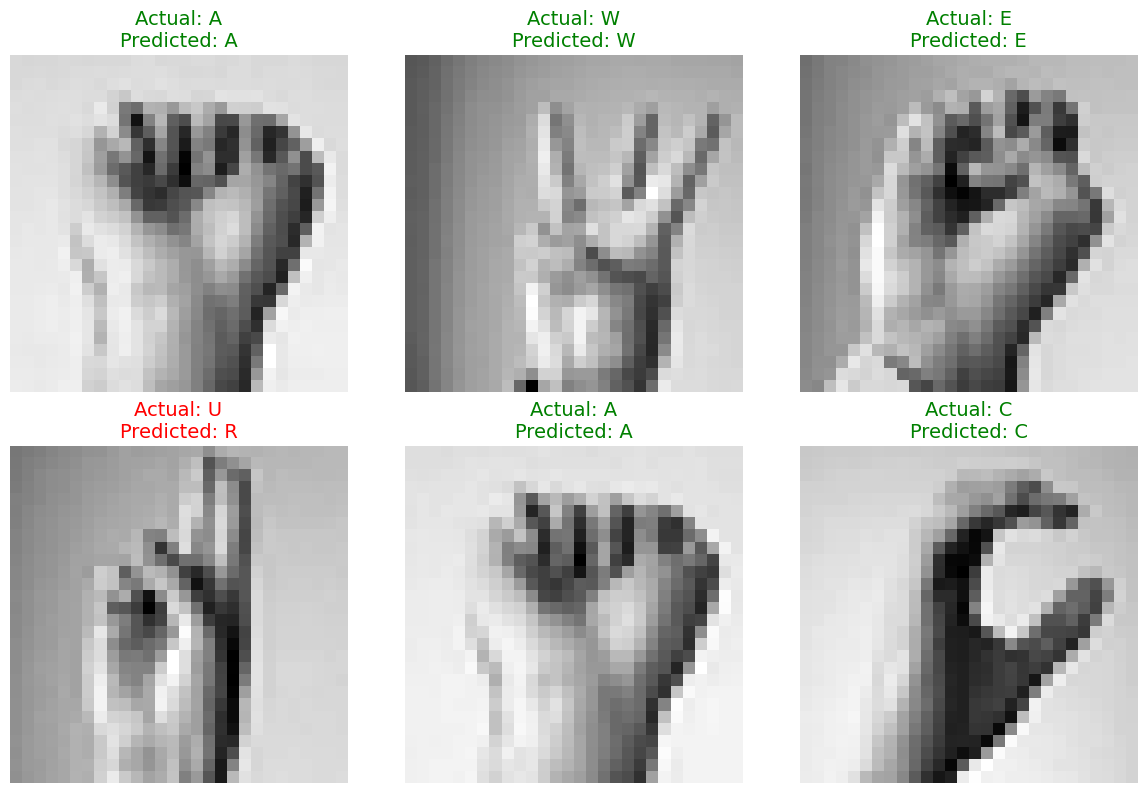

In [39]:
# --- Inference Section: Sign Prediction Demonstration ---

# 1. Define a function to map label indices back to alphabet letters
def label_to_letter(label):
    # In the Sign Language MNIST dataset, labels 0-24 correspond to letters A-Y (with J=9 skipped)
    # Using ASCII code: 65 is 'A', 66 is 'B', etc.
    return chr(65 + label)

# 2. Select a random subset of images from the test dataset
np.random.seed(42)  # For reproducible random selection
num_samples = 6
random_indices = np.random.choice(len(test_images), num_samples, replace=False)

sample_images = test_images[random_indices]
sample_labels = test_labels[random_indices]

# 3. Run inference using the trained model
# model.predict returns a probability distribution across the 25 classes
predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

# 4. Visualize the results in a grid
plt.figure(figsize=(12, 8))
for i in range(num_samples):
    plt.subplot(2, 3, i + 1)
    
    # Reshape the image from (28, 28, 1) back to (28, 28) for plotting
    img = sample_images[i].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    
    actual_letter = label_to_letter(sample_labels[i])
    predicted_letter = label_to_letter(predicted_labels[i])
    
    # Set title color: green if the prediction is correct, red if incorrect
    title_color = 'green' if predicted_labels[i] == sample_labels[i] else 'red'
    plt.title(f"Actual: {actual_letter}\nPredicted: {predicted_letter}", color=title_color, fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()